In [32]:
from pathlib import Path

import numpy as np
import pandas as pd

import xarray as xr
import geopandas as gpd
import salem
from shapely.geometry import box

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

import seaborn as sns

import cartopy.crs as ccrs
from matplotlib.patches import Polygon

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

from project_utils import utils  # Custom functions

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 18})

# About
__Date:__ 05/11/25   
__Author:__ Pat McCornack  
__Purpose:__ This notebook compares the GOES 1km to the GOES 4km dataset.

# Load in and Preprocess data

In [34]:
# Open datasets
root_dir = Path().resolve().parent
clc_1km_fpath = root_dir / 'data' / '03_processed' / 'goes-wrf-clc-1km-binary.nc'
clc_4km_fpath = root_dir / 'data' / '03_processed' / 'goes-wrf-clc-4km-binary.nc'
sci_coast_fpath = root_dir / 'data' / '04_external' / 'sci-coastline' / 'sci-coastline.shp'

# Open datasets
clc_1km_ds = xr.open_dataset(clc_1km_fpath)
clc_4km_ds = xr.open_dataset(clc_4km_fpath)
sci_coast = gpd.read_file(sci_coast_fpath)

# Resample 1km data to match 4km data
resampled_1km = clc_1km_ds.coarsen(lat=4, lon=4, boundary='trim').mean()
resampled_1km = resampled_1km.sel(lon=slice(-119.95, None)) # Clip to match 4km dataset
resampled_1km['goes_binary'] = xr.where(resampled_1km['goes'] > 8.5, 1, 0)  # Recalculate binary based on coarsened raster

# make a 4km dataset matching hours in the 1km dataset (daylight hours)
matching_times = np.intersect1d(clc_4km_ds['time'], resampled_1km['time'])
clc_4km_daytime = clc_4km_ds.sel(time=matching_times)
clc_4km_daytime


<xarray.Dataset> Size: 123MB
Dimensions:        (lat: 11, lon: 11, time: 42396)
Coordinates:
  * lat            (lat) float32 44B 33.82 33.85 33.88 ... 34.09 34.13 34.16
  * lon            (lon) float32 44B -119.9 -119.9 -119.8 ... -119.5 -119.5
  * time           (time) datetime64[ns] 339kB 1996-05-31T17:00:00 ... 2018-0...
Data variables:
    cldfra         (time, lat, lon) float32 21MB ...
    goes_binary    (time, lat, lon) float32 21MB ...
    cldfra_binary  (time, lat, lon) int64 41MB ...
    match          (time, lat, lon) int64 41MB ...

# Map of % CLC over whole record

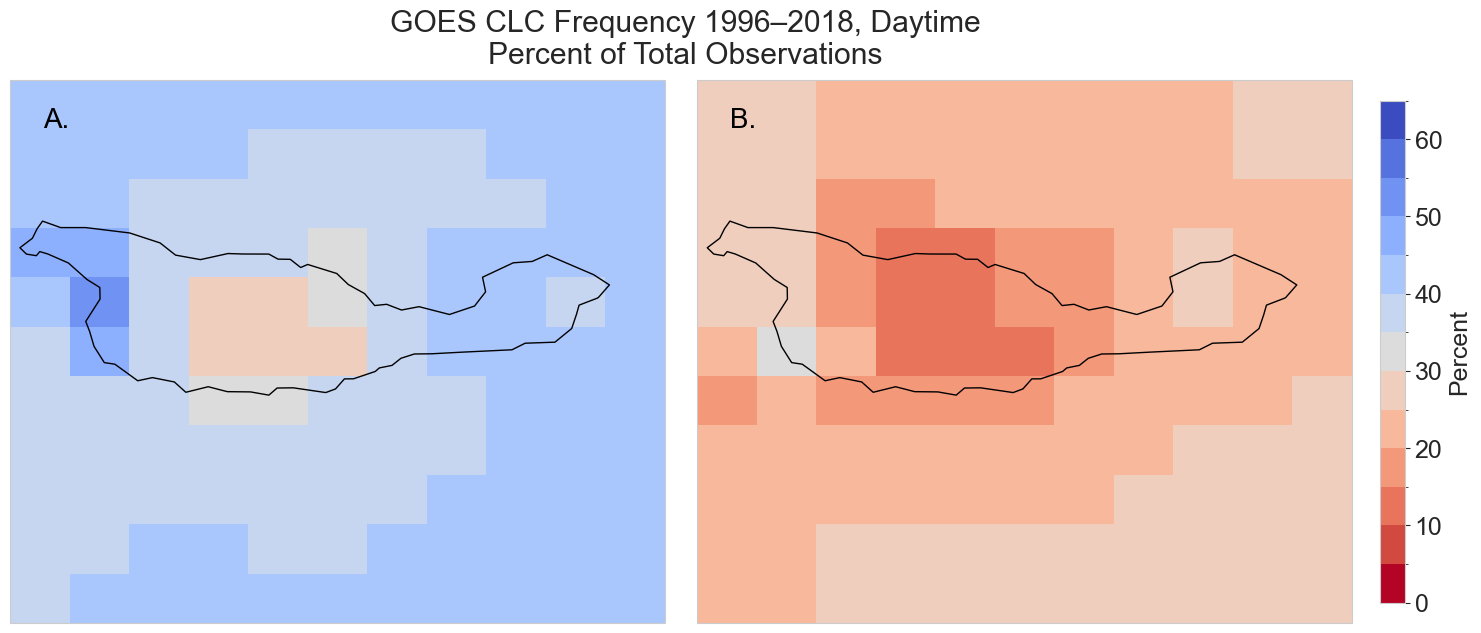

In [45]:
# Settings
cmap = 'coolwarm_r'
var = 'goes_binary'
levels = np.arange(0, 70, 5)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)

# Year range for label
min_year = int(resampled_1km['time'].min().dt.year)
max_year = int(resampled_1km['time'].max().dt.year)

# Compute % frequency for both datasets
resampled_1km_freq = (resampled_1km[var].sum('time') / resampled_1km[var].count('time')) * 100
clc_4km_freq = (clc_4km_daytime[var].sum('time') / clc_4km_daytime[var].count('time')) * 100

# Plot setup
fig, ax = plt.subplots(1, 2, figsize=(18, 12), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot resampled_1km
resampled_1km_freq.plot(ax=ax[0], add_colorbar=False, norm=norm, cmap=cmap)
ax[0].text(0.05, 0.95, 'A.', transform=ax[0].transAxes,
           fontsize=20, ha='left', va='top', color='black')
ax[0].coastlines()

# Plot clc_4km_daytime
clc_4km_freq.plot(ax=ax[1], add_colorbar=False, norm=norm, cmap=cmap)
ax[1].text(0.05, 0.95, 'B.', transform=ax[1].transAxes,
           fontsize=20, ha='left', va='top', color='black')
ax[1].coastlines()

# Adjust layout
plt.subplots_adjust(wspace=0.05)

# Shared colorbar
cbar = fig.colorbar(
    clc_4km_freq.plot(add_colorbar=False, cmap=cmap, norm=norm),
    ax=ax,
    orientation='vertical',
    fraction=0.018,
    pad=0.02,
    label='Percent'
)

# Title
fig.suptitle(f'GOES CLC Frequency {min_year}–{max_year}, Daytime\nPercent of Total Observations',
             y=0.78)

plt.show()


# Yearly timeseries of CLC frequencies

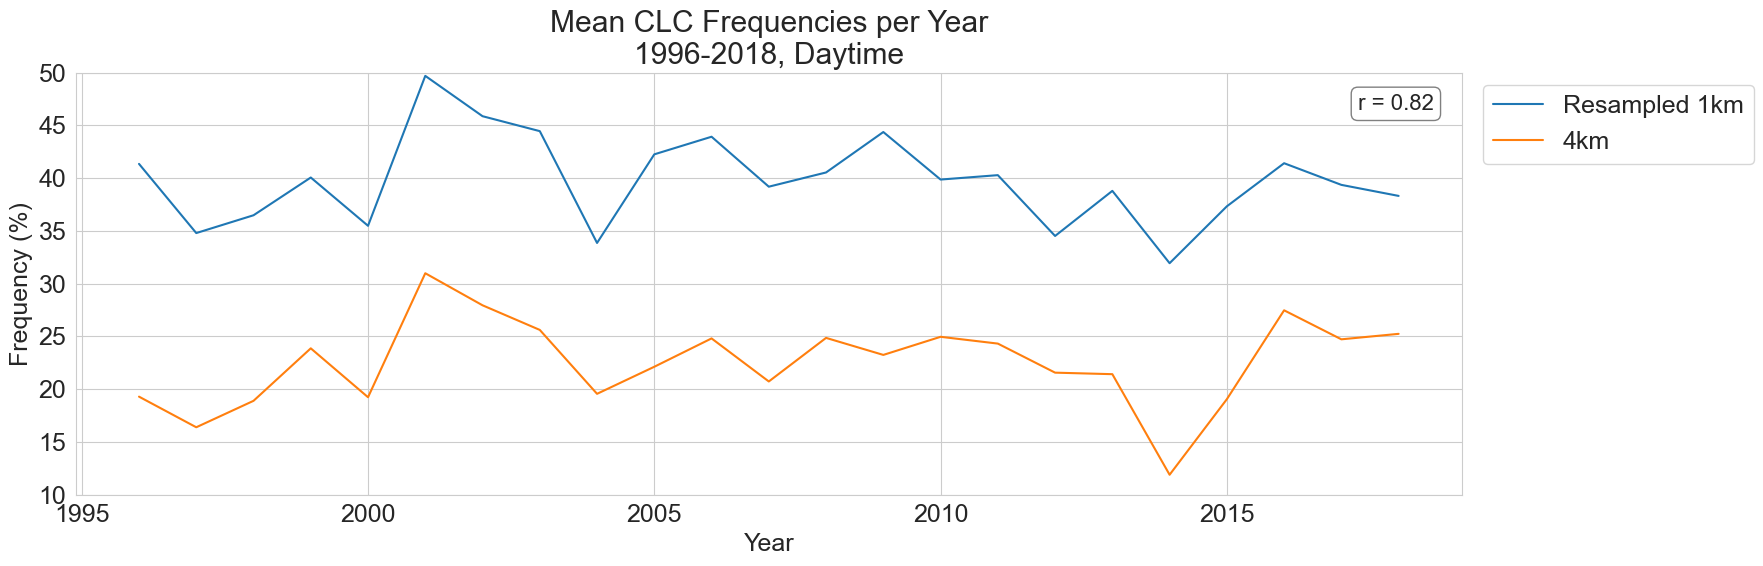

In [36]:
# Group 1km
resampled_1km_gp = resampled_1km.groupby('time.year').sum()
total_count = resampled_1km.groupby('time.year').count()
resampled_1km_gp = resampled_1km_gp / total_count * 100
resampled_1km_gp = resampled_1km_gp.groupby('year').mean(dim=['lat', 'lon'])

# Group 4km
clc_4km_gp = clc_4km_ds.groupby('time.year').sum()
total_count = clc_4km_ds.groupby('time.year').count()
clc_4km_gp = clc_4km_gp / total_count * 100
clc_4km_gp = clc_4km_gp.groupby('year').mean(dim=['lat', 'lon'])

# Make single dataframe
df_gp = resampled_1km_gp[['goes_binary']].to_dataframe()
df_4km_gp = clc_4km_gp[['goes_binary']].to_dataframe()
df_gp['clc_4km'] = df_4km_gp['goes_binary']
df_gp = df_gp.rename({'goes_binary' : 'clc_1km'}, axis=1)
df_gp

correlation = round(np.corrcoef(df_gp['clc_1km'], df_gp['clc_4km'])[0,1],2)

fig, ax = plt.subplots(figsize=(18,6))
sns.lineplot(data=df_gp,
             x='year',
             y='clc_1km',
             label='Resampled 1km')
sns.lineplot(data=df_gp,
             x='year',
             y='clc_4km',
             label='4km')

ax.set(title='Mean CLC Frequencies per Year\n1996-2018, Daytime',
       xlabel='Year',
       ylabel='Frequency (%)')
plt.legend(loc='upper right', bbox_to_anchor=(1.22, 1))

# Add annotation
ax.text(0.98, 0.95, f'r = {correlation:.2f}',
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=16, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))
ax.set_ylim(10,50)


plt.tight_layout()

plt.show()


# Yearly timeseries of frequencies - ocean vs. island

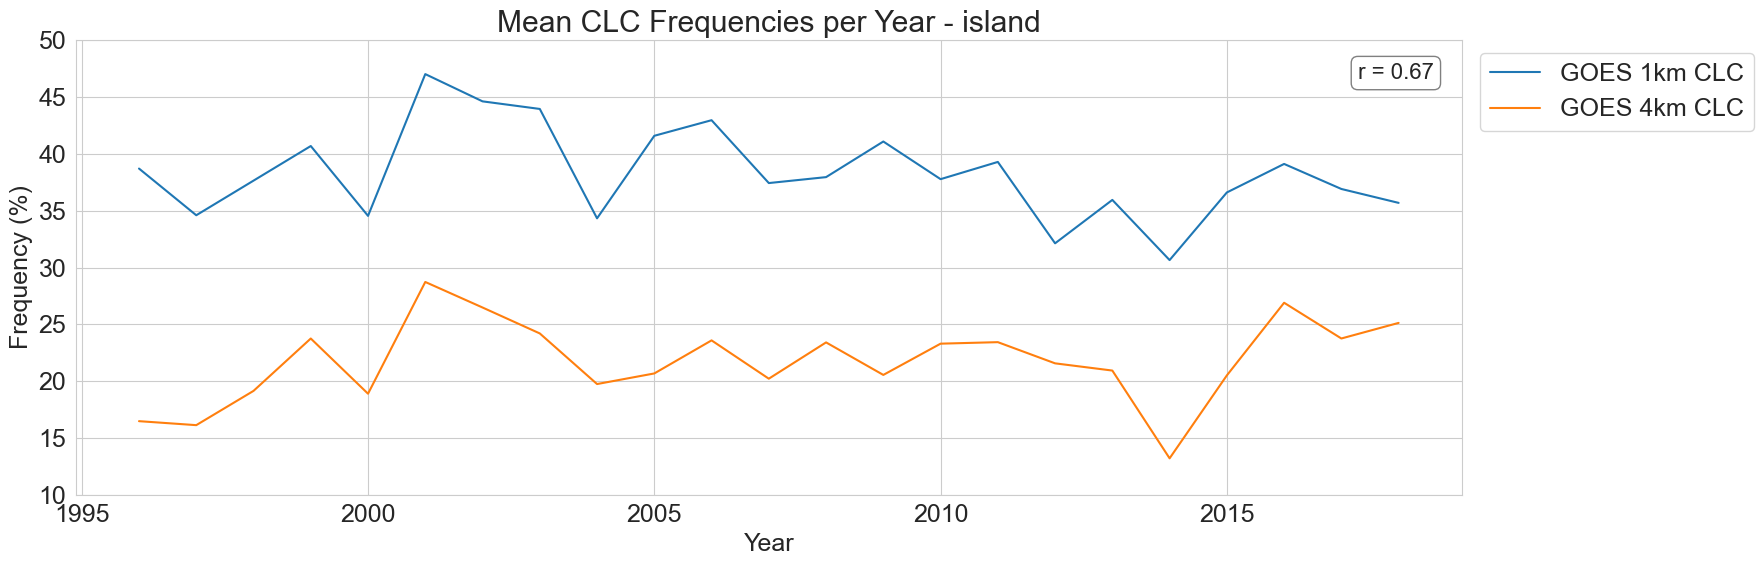

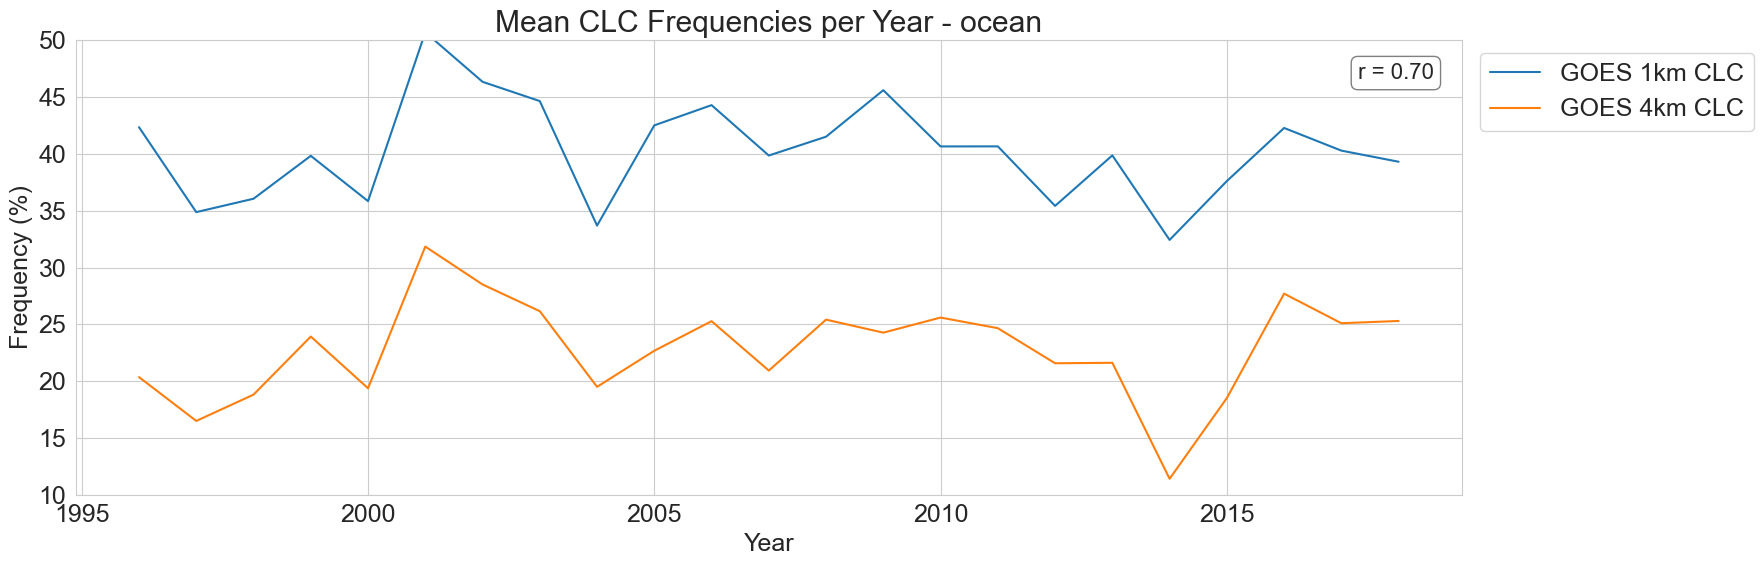

In [ ]:
island_masked_rsmp = resampled_1km.salem.roi(shape=sci_coast, all_touched=True)  # Clip to pixels intersecting the island
island_mask = island_masked_rsmp.sel(time='2014-08-30T12:00:00.000000000')['goes_binary']  # Use this as mask - arbitrary timestamp
ocean_masked_rsmp = resampled_1km.where(np.isnan(island_mask))  # invert the island mask

island_masked_4km = clc_4km_ds.salem.roi(shape=sci_coast, all_touched=True)  # Clip to pixels intersecting the island
island_mask = island_masked_rsmp.sel(time='2014-08-30T12:00:00.000000000')['goes_binary']  # Use this as mask
ocean_masked_4km = clc_4km_ds.where(np.isnan(island_mask))  # invert the island mask


dict_list = [
    {'rsmp_mask' : island_masked_rsmp,
     '4km_mask' : island_masked_4km,
     'all_touched' : True,
     'type' : 'island'},
     
    {'rsmp_mask' : ocean_masked_rsmp,
     '4km_mask' : ocean_masked_4km,
     'all_touched' : False,
     'type' : 'ocean'}
]

for masked in dict_list:
        ds_gp_rsmp = masked['rsmp_mask'].groupby('time.year').sum()
        total_count = masked['rsmp_mask'].groupby('time.year').count()
        ds_gp_rsmp = ds_gp_rsmp / total_count * 100
        ds_gp_rsmp = ds_gp_rsmp.groupby('year').mean(dim=['lat', 'lon'])
        df_gp_rsmp = ds_gp_rsmp[['goes_binary']].to_dataframe()
        correlation = round(np.corrcoef(df_gp_rsmp['goes_binary'], df_gp_4km['goes_binary'])[0,1],2)

        ds_gp_4km = masked['4km_mask'].groupby('time.year').sum()
        total_count = masked['4km_mask'].groupby('time.year').count()
        ds_gp_4km = ds_gp_4km / total_count * 100
        ds_gp_4km = ds_gp_4km.groupby('year').mean(dim=['lat', 'lon'])
        df_gp_4km = ds_gp_4km[['goes_binary']].to_dataframe()

        fig, ax = plt.subplots(figsize=(18,6))
        sns.lineplot(data=df_gp_rsmp,
                x='year',
                y='goes_binary',
                label='GOES 1km CLC')
        sns.lineplot(data=df_gp_4km,
                x='year',
                y='goes_binary',
                label='GOES 4km CLC')
        ax.set(title=f'Mean CLC Frequencies per Year - {masked['type']}',
        xlabel='Year',
        ylabel='Frequency (%)')
        plt.legend(loc='upper right', bbox_to_anchor=(1.22, 1))

        ax.text(0.98, 0.95, f'r = {correlation:.2f}',
                transform=ax.transAxes,
                ha='right', va='top',
                fontsize=16, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))
        ax.set_ylim(10, 50)


        plt.tight_layout()

        plt.show()


# AOI Analysis

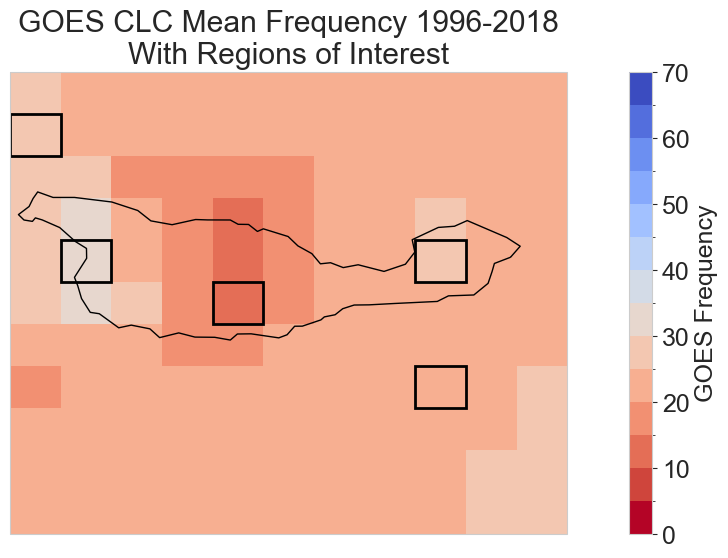

In [ ]:
# Create Regions of Interest

# Define centers of regions of interest
site_dict = {
    'site' : ['west-end', 'coche-point', 'inland', 'nw-ocean', 'se-ocean'],
    'lat' : [34.012499, 34.033456, 34.00346, 34.12030, 33.91093],
    'lon' : [-119.882897, -119.600946, -119.76288, -119.95199, -119.60004]
}

site_df = pd.DataFrame(site_dict)

# Get regions of interest using centers
bounds_df = pd.DataFrame()
for i, site in site_df.iterrows():
    bounds_df = pd.concat([bounds_df, utils.get_bounds(clc_4km_ds, site, resolution='4_km')])

site_df = site_df.merge(bounds_df, on='site')
site_df
# Plot regions of interest
min_year = int(clc_4km_ds['time'].min().dt.year)
max_year = int(clc_4km_ds['time'].max().dt.year)

# Group over entire dataset
ds_gp = clc_4km_ds.sum('time')
total_count = clc_4km_ds.count('time')
ds_gp = (ds_gp / total_count) * 100
goes_da = ds_gp['goes_binary']

# Plot regions of interest over GOES frequencies
fig, ax = plt.subplots(figsize=(16,6), subplot_kw={'projection': ccrs.PlateCarree()})
levels = np.arange(0,75,5)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)
goes_da.plot(ax=ax, cbar_kwargs={"shrink": 1, "label": "GOES Frequency"}, cmap=cmap, norm=norm)
for i, site in site_df.iterrows():
    polygon = Polygon(site['bounds'], closed=True, edgecolor='black', facecolor='none', linewidth=2)
    ax.add_patch(polygon)
ax.set(title=f'GOES CLC Mean Frequency {min_year}-{max_year}\nWith Regions of Interest')
ax.coastlines()
plt.show()

## Regional scatterplots 

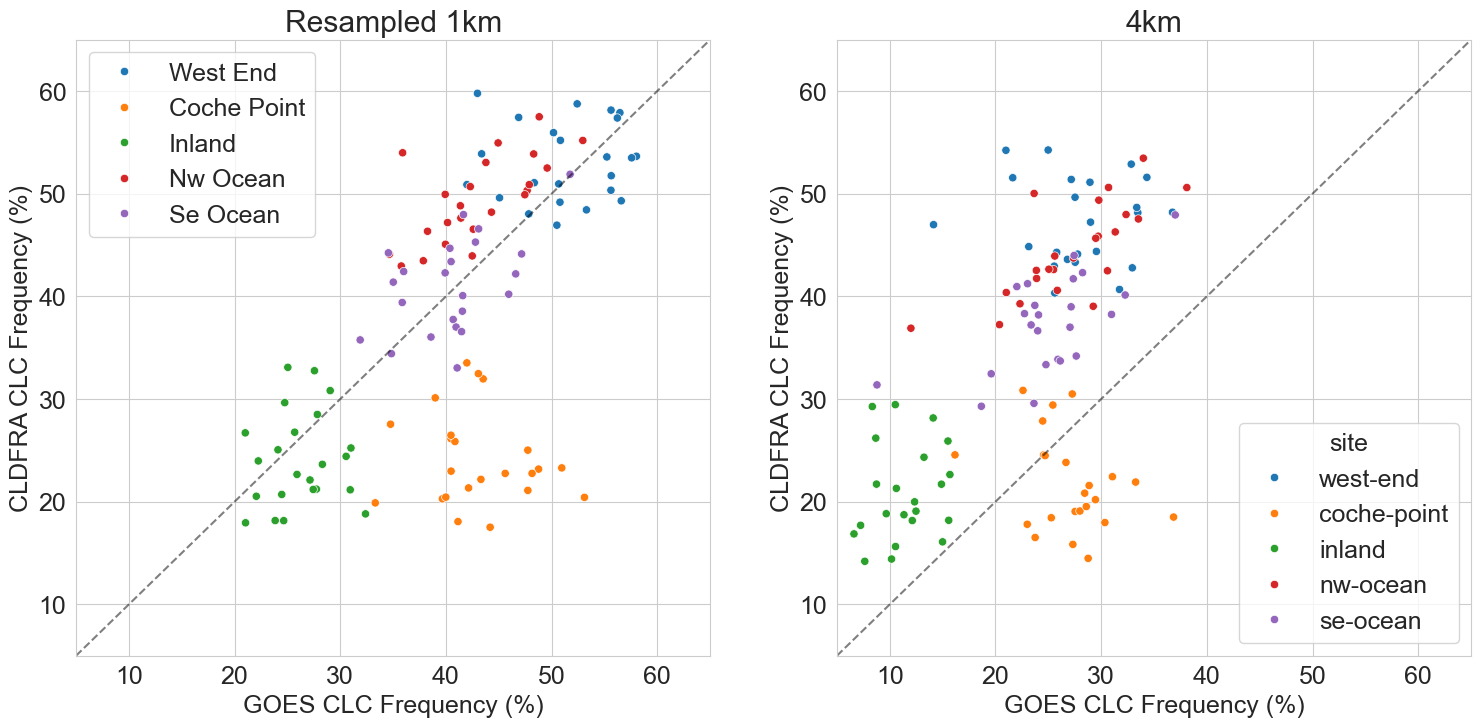

In [41]:
# Get yearly frequencies
freq_1km_df = utils.get_yearly_freq(resampled_1km, site_df)
freq_4km_df = utils.get_yearly_freq(clc_4km_daytime, site_df)

# Scatter plot WRF vs. GOES CLC Frequencies by Year
fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1km data
sns.scatterplot(data=freq_1km_df,
                x='goes_freq',
                y='cldfra_freq',
                hue='site',
                ax=ax[0])
ax[0].set(title='Resampled 1km',
          xlabel='GOES CLC Frequency (%)',
          ylabel='CLDFRA CLC Frequency (%)')

# Plot 4km data
sns.scatterplot(data=freq_4km_df,
                x='goes_freq',
                y='cldfra_freq',
                hue='site',
                ax=ax[1])
ax[1].set(title='4km',
          xlabel='GOES CLC Frequency (%)',
          ylabel='CLDFRA CLC Frequency (%)')

ymin = 5; ymax = 65
xmin = 5; xmax = 65
for a in ax:
       a.set_ylim(ymin, ymax)
       a.set_xlim(xmin, xmax)

# Add diagonal lines
for a in ax:
    xlim = a.get_xlim()
    ylim = a.get_ylim()
    min_val = min(xlim[0], ylim[0])
    max_val = max(xlim[1], ylim[1])
    a.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', alpha=0.5)
    a.set_xlim(xlim)  # Reset in case the plot call changed them
    a.set_ylim(ylim)

# Modify legend labels
labels = freq_1km_df['site'].unique()
formatted_labels = [label.replace('-', ' ').title() for label in labels]
handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend(handles, formatted_labels, title='')

plt.show()
